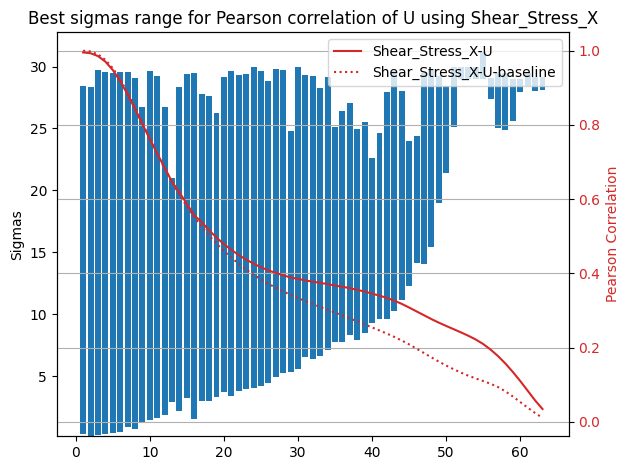

In [1]:
from pathlib import Path

search_folder = Path("dog_search_abs")

import pandas as pd
import numpy as np
import pickle
import re


def get_file_index(file_path):
    return list(map(int, re.findall(r'\d+', str(file_path))))

def read_file(file_path):
    with open(file_path, "rb") as f:
        search_dict = pickle.load(f)
    
    return search_dict


# Build the search array results

search_array = np.empty((3, 3, 63), dtype=object)
# Build an array of shape: 3, 3, 63
# of dict with baseline & layers df

for file in search_folder.iterdir():
    # raw_index shape is: layer[1-64], in, out
    raw_index = get_file_index(file)
    # index shape is: in, out, layer[0-63]
    index = raw_index[1], raw_index[2], raw_index[0] - 1
    search_array[index] = read_file(file)

# Check for missing entries
missing_mask = (search_array == None)
if missing_mask.sum() > 0:
    print("Missing files")
    print(np.where(missing_mask))

def select_max_score(entry):
    return entry["search_df"]["score"].max()

best_results_array = np.vectorize(select_max_score)(search_array)

def select_real_score(entry):
    return entry["search_df"]["score"].max() + entry["baseline"]

best_correlations_array = np.vectorize(select_real_score)(search_array)

def select_baseline(entry):
    return entry["baseline"]

baseline_array = np.vectorize(select_baseline)(search_array)

def get_sigma_select(sigma):
    def select_sigma(entry):
        best_line_idx = entry["search_df"]["score"].idxmax()
        best_line = entry["search_df"].iloc[best_line_idx]
        return best_line[sigma]
    return select_sigma

best_s1_array = np.vectorize(get_sigma_select("s1"))(search_array)
best_s2_array = np.vectorize(get_sigma_select("s2"))(search_array)

import matplotlib.pyplot as plt

def plot_sigma(in_comp_select, out_comp_select):
    out_comp = ["U", "V", "W"]
        
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    in_comp_name = in_comp[in_comp_select]
    sigma_range = best_s2_array - best_s1_array
    fig, ax1 = plt.subplots()
    plt.title(f"Best sigmas range for Pearson correlation of {out_comp[out_comp_select]} using {in_comp_name}")
    ax1.set_ylabel("Sigmas")
    ax1.bar(range(1, 64), sigma_range[in_comp_select, out_comp_select], bottom=best_s1_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    ax2 = ax1.twinx()
    color = "tab:red"
    line, = ax2.plot(range(1, 64), best_correlations_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}", color=color)
    plt.plot(range(1, 64), baseline_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}-baseline", linestyle=":", color=line.get_color())
    ax2.set_ylabel("Pearson Correlation", color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    plt.legend()
    fig.tight_layout()
    plt.grid()
    plt.xlabel("Y layer")
    plt.show()

plot_sigma(1, 0)

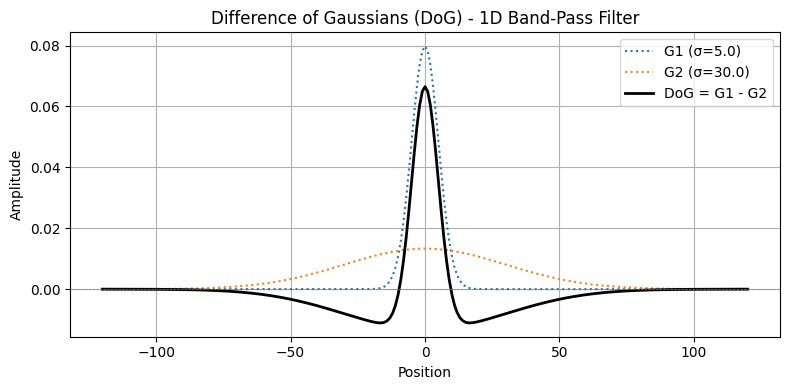

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_dog_1d(sigma1=1.0, sigma2=3.0, truncate=4.0):
    # Define kernel size large enough for both sigmas
    radius = int(truncate * max(sigma1, sigma2))
    kernel_size = 2 * radius + 1
    x = np.linspace(-radius, radius, kernel_size)

    # Build both Gaussians
    g1 = norm.pdf(x, loc=0, scale=sigma1)
    g2 = norm.pdf(x, loc=0, scale=sigma2)

    # Normalize
    g1 /= g1.sum()
    g2 /= g2.sum()

    # DoG = G1 - G2
    dog = g1 - g2

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(x, g1, label=f'G1 (σ={sigma1})', linestyle=":")
    plt.plot(x, g2, label=f'G2 (σ={sigma2})', linestyle=":")
    plt.plot(x, dog, label='DoG = G1 - G2', color='black', linewidth=2)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.title('Difference of Gaussians (DoG) - 1D Band-Pass Filter')
    plt.xlabel('Position')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

visualize_dog_1d(sigma1=5.0, sigma2=30.0)

In [3]:
from space_exploration.beans.training_bean import Training
from space_exploration.beans.dataset_bean import Dataset
from space_exploration.training.training import ModelTraining
from space_exploration.dataset.transforms.AllTransforms import TransformationReferences

dataset_name = "re200-sr1etot"
dataset = Dataset.get_dataset_or_fail(dataset_name)

raw_ds = dataset.get_training_dataset(64, TransformationReferences.DEFAULT_UNCHANGED.transformation, TransformationReferences.DEFAULT_UNCHANGED.transformation, size=300)
norm_ds = dataset.get_training_dataset(64, TransformationReferences.COMPONENT_NORMALIZE.transformation, TransformationReferences.Y_ALONG_COMPONENT_NORMALIZE.transformation, size=300)




⌛ Initializing Dataset...
X...
[########################################] | 100% Completed | 216.84 ms
Y...
[########################################] | 100% Completed | 1.84 ss
Loading std & mean of dataset re200-sr1etot
Loading stds & means of dataset re200-sr1etot
⌛ Initializing Dataset...
X...
[########################################] | 100% Completed | 226.50 ms
Y...
[########################################] | 100% Completed | 1.85 ss


In [34]:

xs = [x for x, y in norm_ds]
ys = [y for x, y in norm_ds]

x = xs[0].numpy()
y = ys[0].numpy()

import pyvista as pv
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

pv.set_jupyter_backend('static')


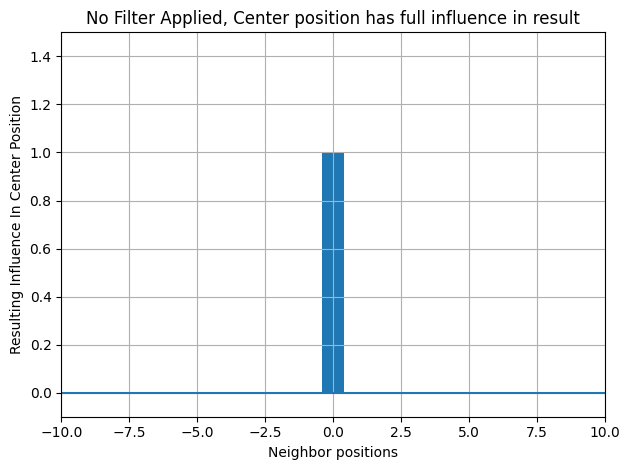

In [4]:
plt.bar([0], [1])
plt.plot([-10, 10], [0, 0])
plt.ylim([-0.1, 1.5])
plt.xlim([-10, 10])
plt.title("No Filter Applied, Center position has full influence in result")
plt.xlabel("Neighbor positions")
plt.ylabel("Resulting Influence In Center Position")
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
positions = [1, 20, 40, 50, 60]

comp_in = 1
comp_out = 0
sigmas = [(best_s1_array[comp_in, comp_out, position], best_s2_array[comp_in, comp_out, position]) for position in positions]



In [6]:
sigmas

[(np.float64(0.13437126039926284), np.float64(28.377186424045583)),
 (np.float64(3.3942365387313984), np.float64(29.669201796557445)),
 (np.float64(9.600218577353429), np.float64(24.631475187557285)),
 (np.float64(25.15066102335135), np.float64(29.98781001536842)),
 (np.float64(28.427235558302137), np.float64(29.450329993495508))]

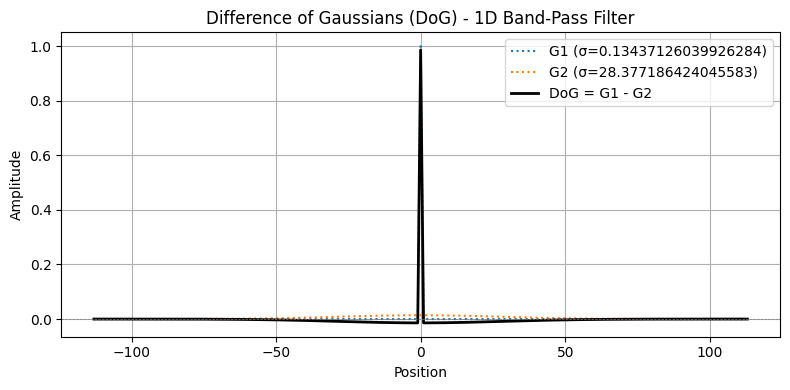

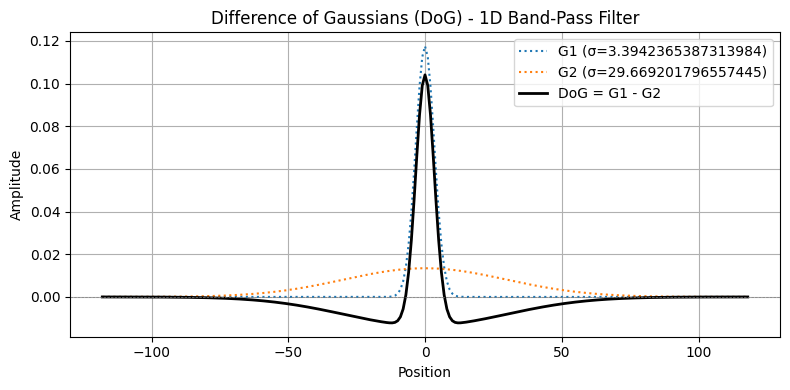

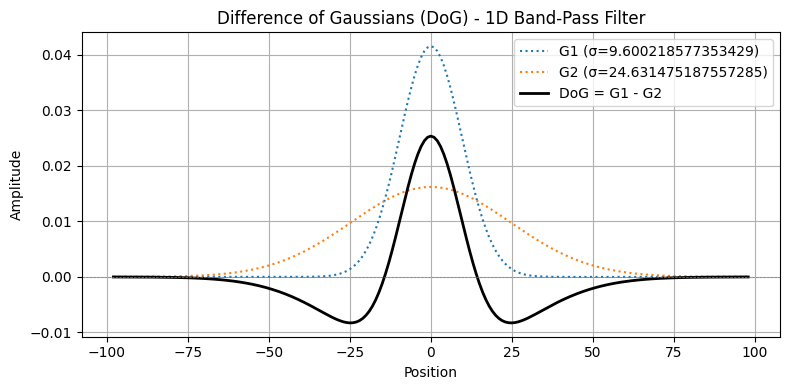

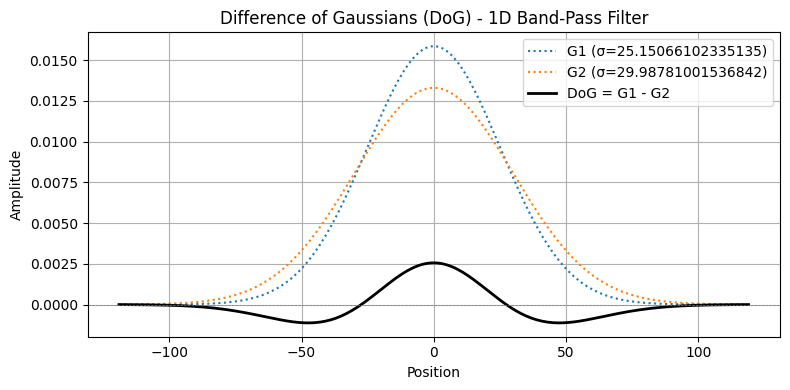

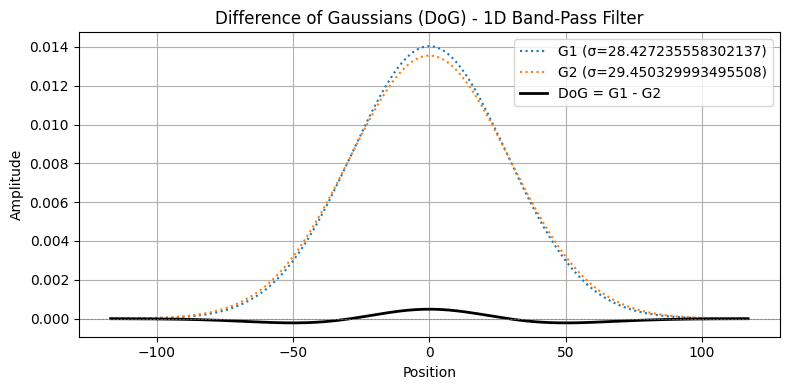

In [7]:
for s1, s2 in sigmas:
    visualize_dog_1d(s1, s2)

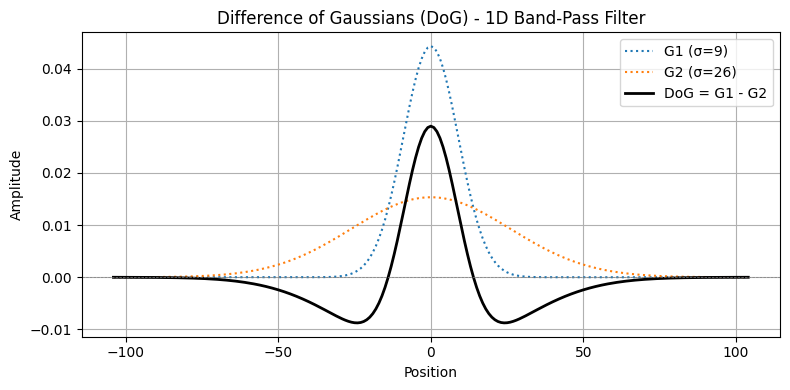

In [26]:
visualize_dog_1d(9, 26)

In [8]:
def visu_layer(x_data):
    grid = get_grid(dataset, 1)
    grid["Normalized Shear Stress X"] = x_data.flatten()
    plotter = pv.Plotter(notebook=True)
    plotter.add_mesh(grid, cmap="inferno")
    plot_utils(plotter)

In [35]:
x_data = x[comp_in, ...].squeeze()
x_data.shape

(64, 64)

In [36]:
from scipy.ndimage import gaussian_filter

def apply_dog(img, s1, s2):
    return gaussian_filter(img, s1) - gaussian_filter(img, s2)

dogs = [apply_dog(x_data, s1, s2) for s1, s2 in sigmas]
    


In [37]:
def plot_utils(plotter):
    plotter.camera_position = [
    (2, 10, 0.5),  # camera position
    (2, 0, 0),     # focal point
    (0, 1, 0),     # up direction → Y is up
    ]
    # plotter.camera.zoom = .005
    plotter.camera.roll = 90
    plotter.show_axes()
    plotter.disable_shadows()
    plotter.show()

def get_grid(dataset, y_lim):
    subspace = dataset.channel.get_simulation_channel()
    grid = pv.RectilinearGrid(subspace.x_dimension, subspace.y_dimension[:y_lim], subspace.z_dimension)
    return grid


In [38]:
x = x[0, ...].squeeze()

2025-08-08 11:46:57.275 (2148.449s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5653df37a160): Unable to eglMakeCurrent: 12291
2025-08-08 11:46:57.300 (2148.475s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x56541ac28540): Unable to eglMakeCurrent: 12291
2025-08-08 11:46:57.336 (2148.511s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x5653df37a160): Unable to eglMakeCurrent: 12291


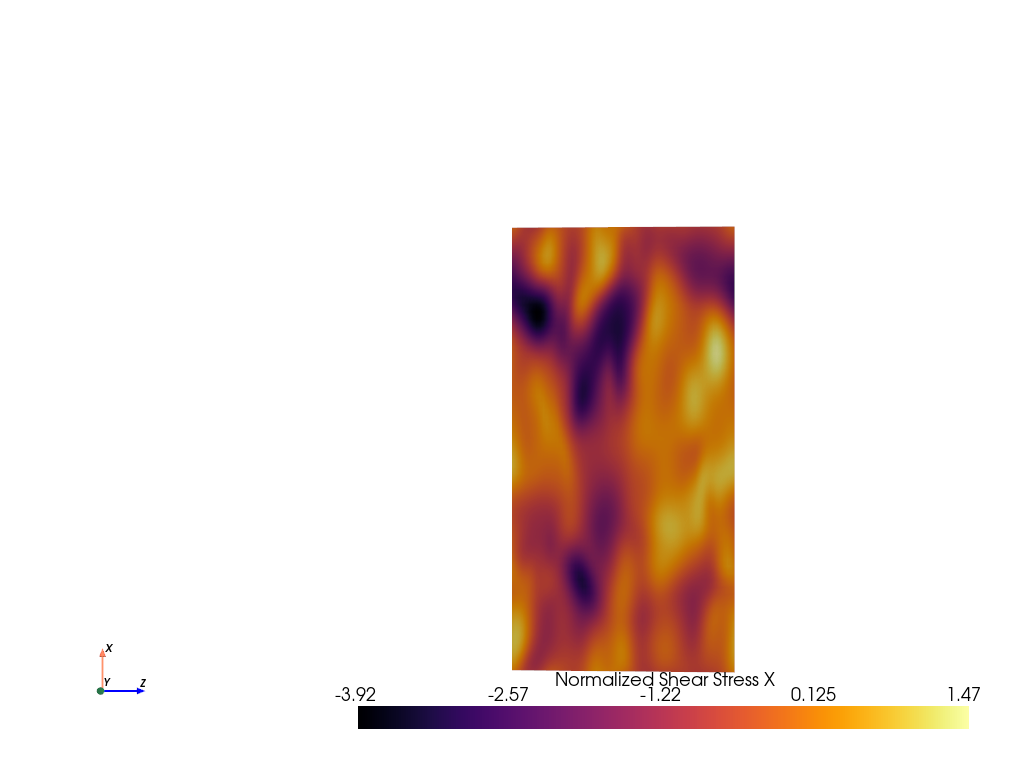

In [45]:
visu_layer(x)

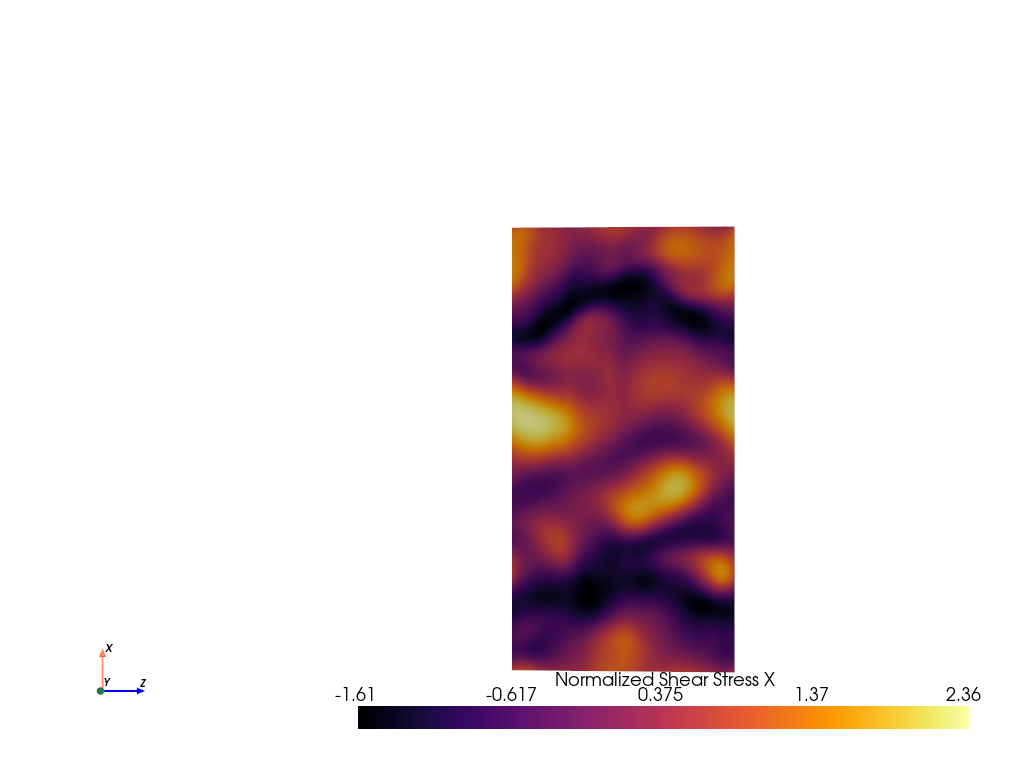

In [40]:
visu_layer(dogs[0])

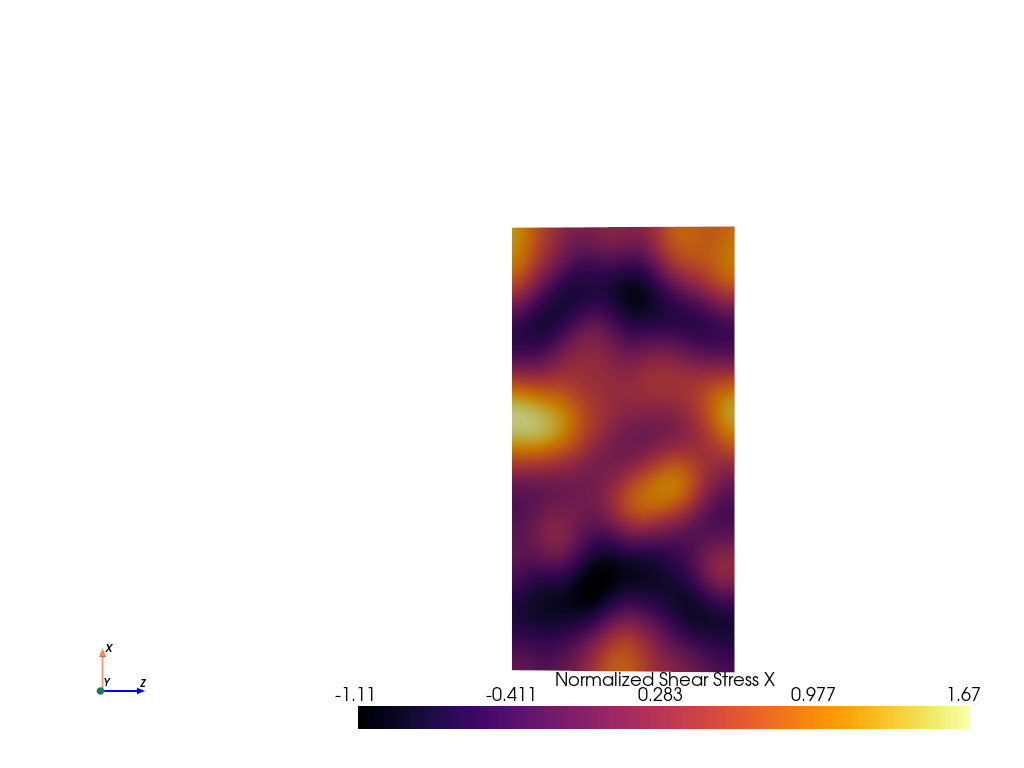

In [41]:
visu_layer(dogs[1])

2025-08-08 11:46:38.843 (2130.018s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x565419887ce0): Unable to eglMakeCurrent: 12291
2025-08-08 11:46:38.866 (2130.041s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x56541ac28540): Unable to eglMakeCurrent: 12291


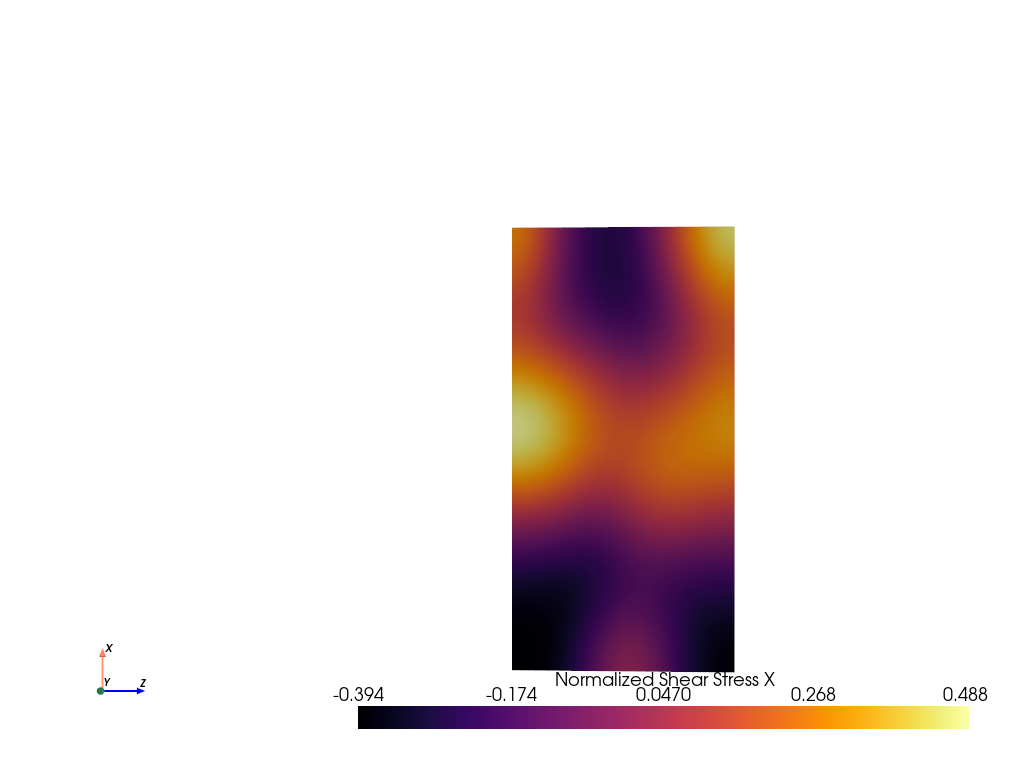

In [42]:
visu_layer(dogs[2])

2025-08-08 11:46:39.332 (2130.507s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x56541a01e450): Unable to eglMakeCurrent: 12291
2025-08-08 11:46:39.357 (2130.532s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x56541ac28540): Unable to eglMakeCurrent: 12291
2025-08-08 11:46:39.388 (2130.563s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x56541a01e450): Unable to eglMakeCurrent: 12291


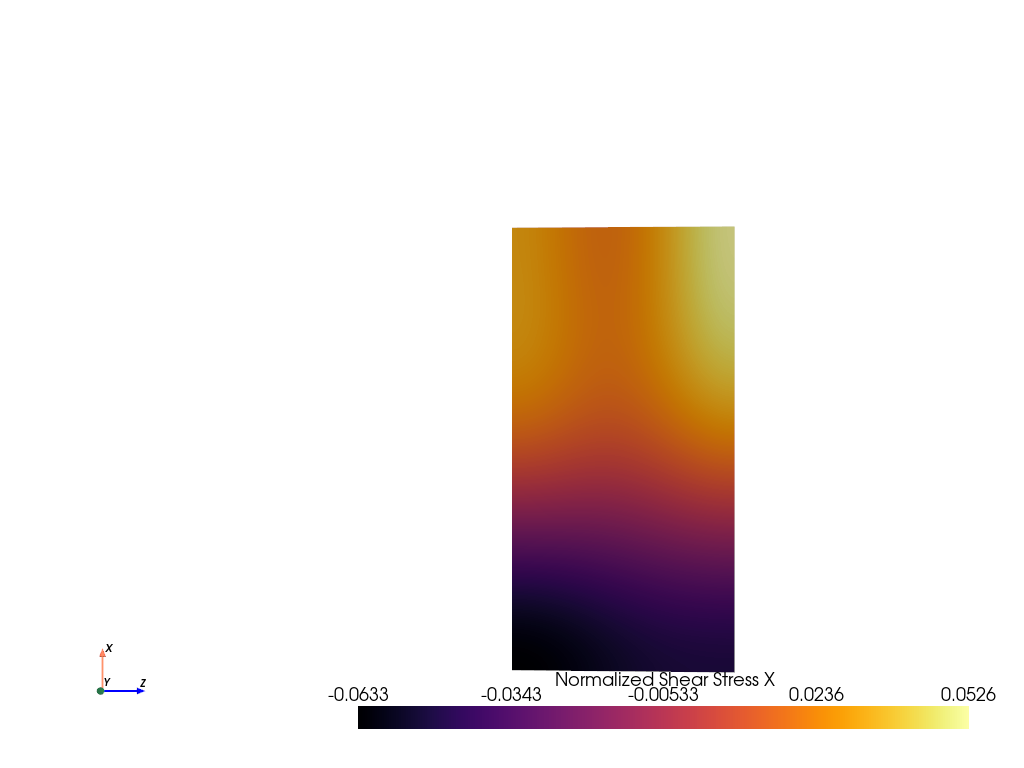

In [43]:
visu_layer(dogs[3])

2025-08-08 11:46:41.048 (2132.223s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x565419bfe8f0): Unable to eglMakeCurrent: 12291
2025-08-08 11:46:41.075 (2132.250s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x56541ac28540): Unable to eglMakeCurrent: 12291
2025-08-08 11:46:41.112 (2132.286s) [    1500C22731C0] vtkEGLRenderWindow.cxx:674   WARN| vtkEGLRenderWindow (0x565419bfe8f0): Unable to eglMakeCurrent: 12291


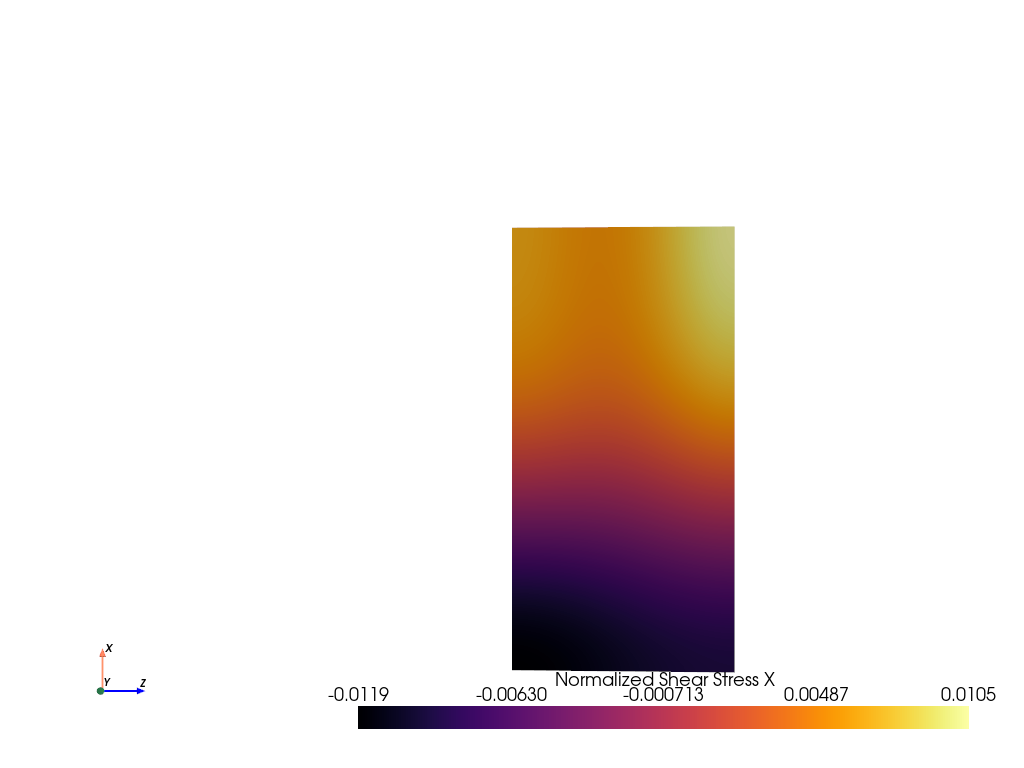

In [44]:
visu_layer(dogs[4])